# Salary Prediction — End-to-End ML Pipeline

**Goal:** Predict an employee's annual salary from features such as years of
experience, education level, job title, age, gender, and location.

**Task type:** Regression

**Pipeline overview:** data loading → EDA → preprocessing → baseline model →
hyperparameter tuning with cross-validation → final model → evaluation →
export for deployment in a Streamlit app.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
DATA_PATH = "../data/salary_data.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1200, 7)


,Age,Gender,Education Level,Job Title,Years of Experience,Location,Salary
0,27.0,Male,Master's,Graphic Designer,6.0,Austin,72786.92
1,34.0,Male,Master's,Junior Developer,7.1,Seattle,97736.39
2,38.0,Female,PhD,HR Manager,13.9,Seattle,152302.50
3,46.0,Male,High School,Product Manager,13.6,Denver,80954.42
4,36.0,Female,PhD,Product Manager,6.5,Chicago,137342.66


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1176 non-null   float64
 1   Gender               1176 non-null   str    
 2   Education Level      1176 non-null   str    
 3   Job Title            1200 non-null   str    
 4   Years of Experience  1176 non-null   float64
 5   Location             1200 non-null   str    
 6   Salary               1200 non-null   float64
dtypes: float64(3), str(4)
memory usage: 65.8 KB


In [ ]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1176.0,NaN,NaN,NaN,37.672619,9.619438,21.0,31.0,38.0,44.0,65.0
Gender,1176,2,Female,597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education Level,1176,4,Bachelor's,515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Title,1200,20,Sales Associate,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years of Experience,1176.0,NaN,NaN,NaN,9.295153,6.566247,0.0,4.0,8.7,14.0,32.6
Location,1200,10,New York,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,1200.0,NaN,NaN,NaN,95863.460783,31596.511699,28000.0,72236.4025,94245.64,116179.7,196805.75


In [ ]:
# Missing values overview
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
Age,24,2.0
Gender,24,2.0
Education Level,24,2.0
Job Title,0,0.0
Years of Experience,24,2.0
Location,0,0.0
Salary,0,0.0


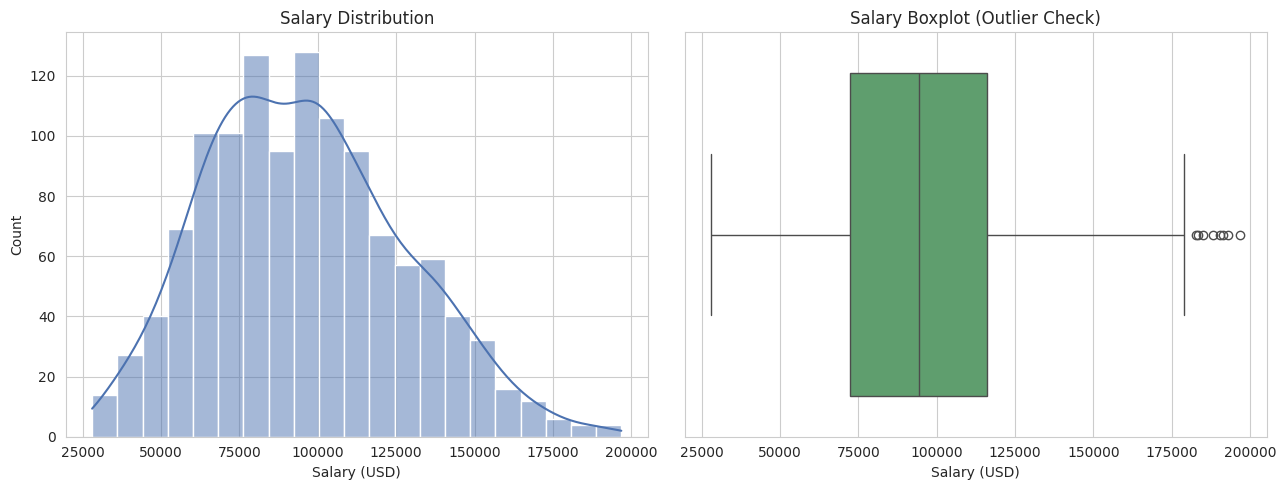

In [ ]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["Salary"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("Salary (USD)")

sns.boxplot(x=df["Salary"], ax=axes[1], color="#55A868")
axes[1].set_title("Salary Boxplot (Outlier Check)")
axes[1].set_xlabel("Salary (USD)")

plt.tight_layout()
plt.show()


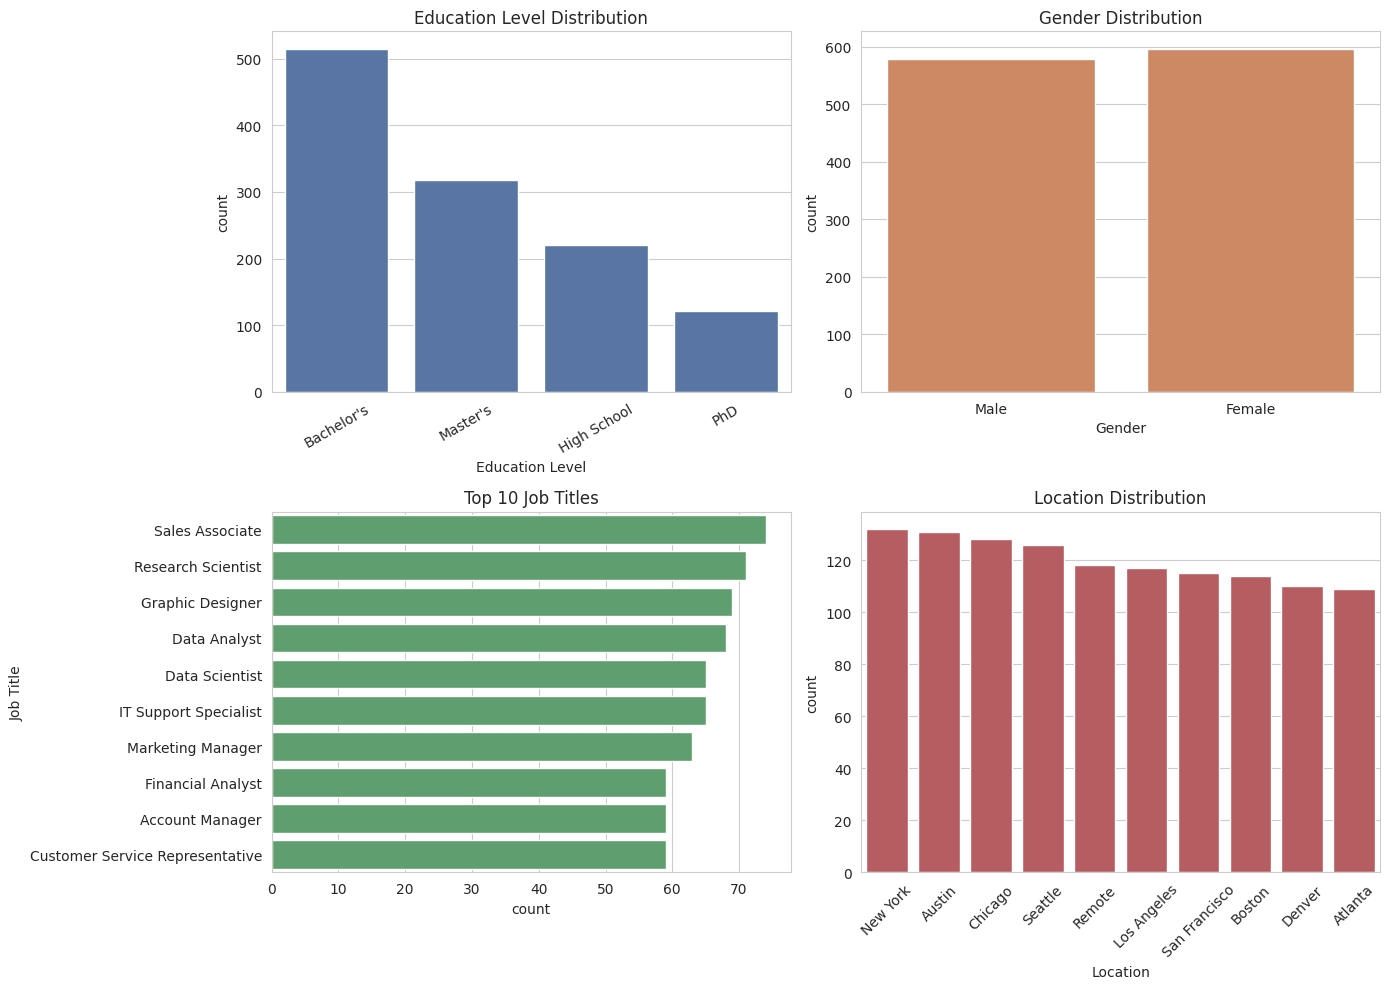

In [ ]:
# "Class distribution" for the categorical features (since this is a
# regression task, there's no target class - we inspect categorical feature
# balance instead, which plays the same diagnostic role)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Education Level", order=df["Education Level"].value_counts().index,
              ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Education Level Distribution")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="Gender", ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("Gender Distribution")

top_titles = df["Job Title"].value_counts().head(10).index
sns.countplot(data=df[df["Job Title"].isin(top_titles)], y="Job Title",
              order=top_titles, ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title("Top 10 Job Titles")

if "Location" in df.columns:
    sns.countplot(data=df, x="Location", order=df["Location"].value_counts().index,
                  ax=axes[1, 1], color="#C44E52")
    axes[1, 1].set_title("Location Distribution")
    axes[1, 1].tick_params(axis="x", rotation=45)
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Sample inspection: a few random rows across the salary spectrum
df.sort_values("Salary").iloc[[0, len(df)//4, len(df)//2, (3*len(df))//4, -1]]


,Age,Gender,Education Level,Job Title,Years of Experience,Location,Salary
946,39.0,Female,High School,Sales Associate,6.3,Remote,28000.00
143,38.0,Male,High School,Marketing Manager,4.1,New York,72261.62
709,41.0,Male,Bachelor's,Operations Manager,5.8,San Francisco,94247.90
976,29.0,Female,Master's,Business Analyst,6.5,San Francisco,116293.88
604,58.0,Male,PhD,Marketing Manager,24.1,San Francisco,196805.75


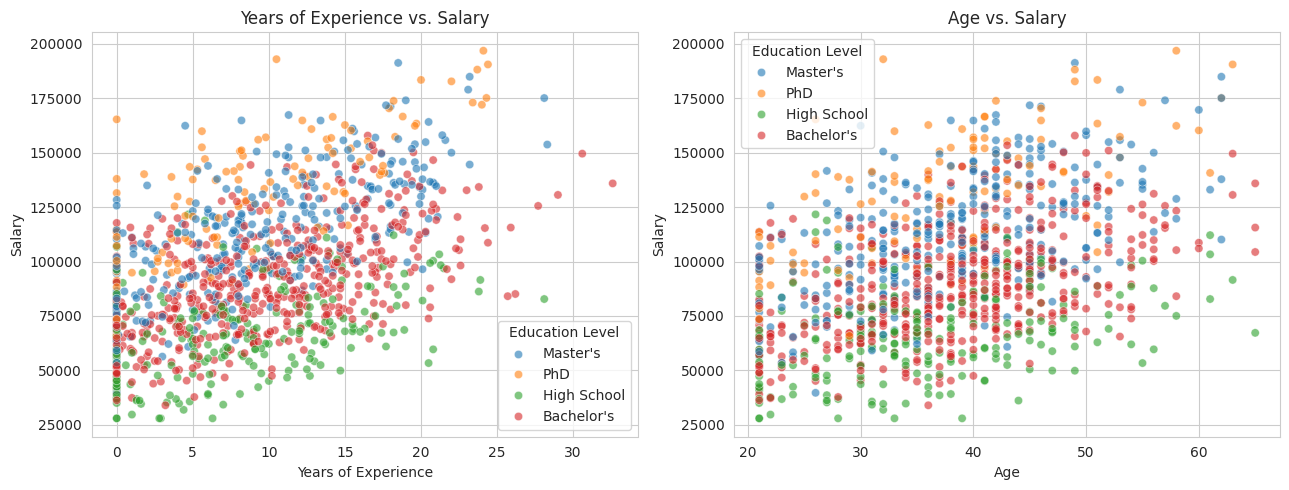

In [ ]:
# Numeric relationships: experience and age vs. salary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="Years of Experience", y="Salary", hue="Education Level",
                 alpha=0.6, ax=axes[0])
axes[0].set_title("Years of Experience vs. Salary")

sns.scatterplot(data=df, x="Age", y="Salary", hue="Education Level", alpha=0.6, ax=axes[1])
axes[1].set_title("Age vs. Salary")

plt.tight_layout()
plt.show()


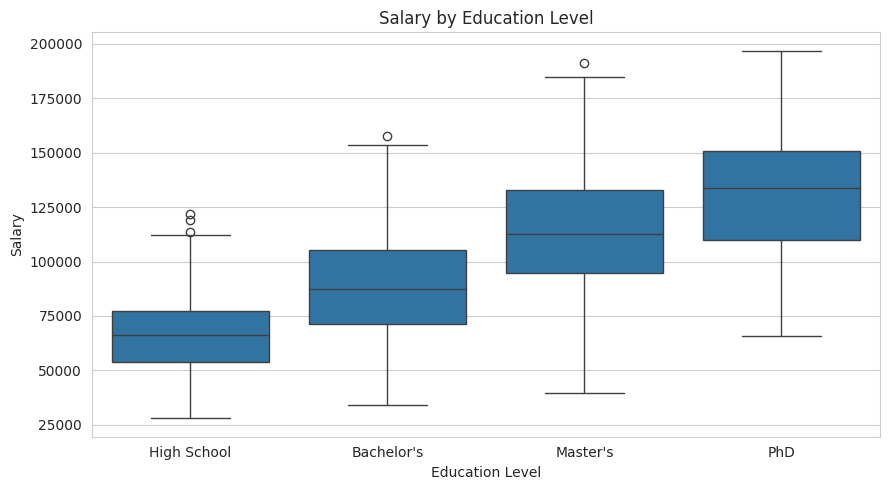

In [ ]:
# Salary by education level and job title (categorical relationships)
fig, axes = plt.subplots(1, 1, figsize=(9, 5))
order = df.groupby("Education Level")["Salary"].median().sort_values().index
sns.boxplot(data=df, x="Education Level", y="Salary", order=order, ax=axes)
axes.set_title("Salary by Education Level")
plt.tight_layout()
plt.show()


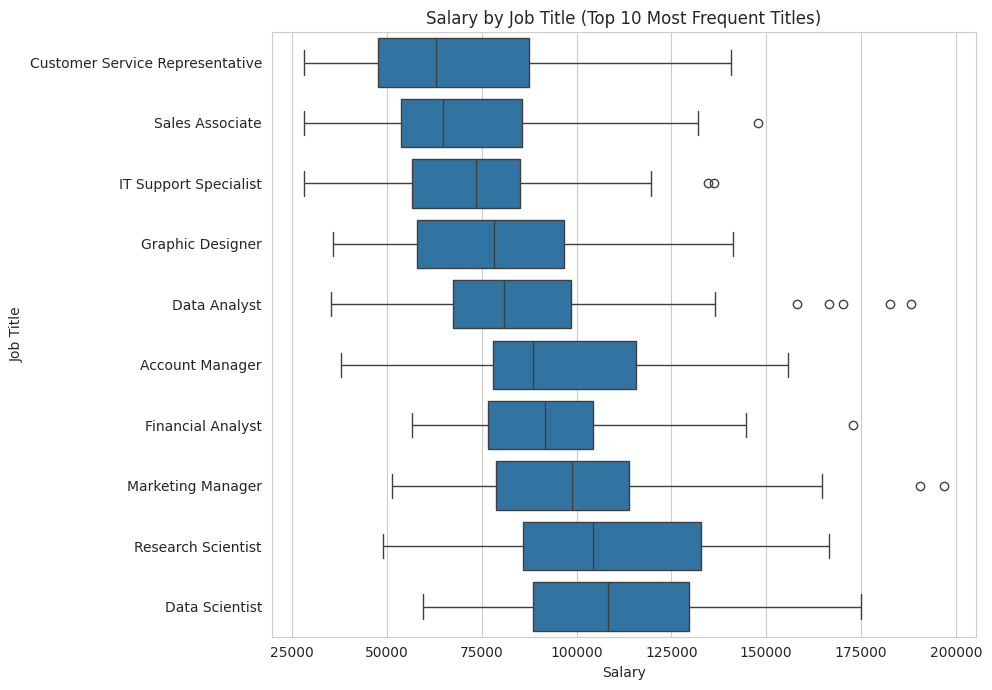

In [ ]:
plt.figure(figsize=(10, 7))
top10_titles = df["Job Title"].value_counts().head(10).index
order = (df[df["Job Title"].isin(top10_titles)]
         .groupby("Job Title")["Salary"].median().sort_values().index)
sns.boxplot(data=df[df["Job Title"].isin(top10_titles)], x="Salary", y="Job Title", order=order)
plt.title("Salary by Job Title (Top 10 Most Frequent Titles)")
plt.tight_layout()
plt.show()


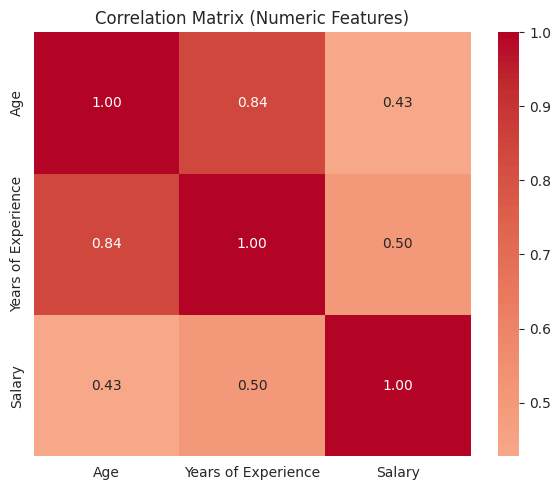

In [ ]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()


**EDA takeaways:**
- Salary is right-skewed with a long tail toward senior/leadership roles.
- Years of experience shows a strong positive relationship with salary, and
  this relationship is steeper for higher education levels — suggesting an
  interaction effect.
- Education level clearly shifts the salary distribution upward (PhD > Master's
  > Bachelor's > High School).
- A small percentage of rows have missing values in `Age`, `Gender`,
  `Education Level`, and `Years of Experience`, which we handle in preprocessing.


In [ ]:
df = df.dropna(subset=["Salary"]).reset_index(drop=True)

TARGET = "Salary"
numeric_features = ["Age", "Years of Experience"]
categorical_features = [c for c in ["Gender", "Education Level", "Job Title", "Location"]
                         if c in df.columns]

X = df[numeric_features + categorical_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (960, 6), Test size: (240, 6)


In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Model Building

### 5.1 Baseline model
A simple `LinearRegression` model gives us a baseline to beat.


In [ ]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline Linear Regression -> MAE: {baseline_mae:,.2f} | RMSE: {baseline_rmse:,.2f} | R2: {baseline_r2:.4f}")


Baseline Linear Regression -> MAE: 5,982.31 | RMSE: 7,981.30 | R2: 0.9334


In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE)),
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring="r2")

print(f"Random Forest 5-fold CV R2 scores: {np.round(cv_scores, 4)}")
print(f"Mean CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Random Forest 5-fold CV R2 scores: [0.8929 0.8506 0.8225 0.841  0.8614]
Mean CV R2: 0.8537 (+/- 0.0234)


In [ ]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")


Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV R2: 0.8549


In [ ]:
final_model = grid_search.best_estimator_

# Quick comparison against Gradient Boosting as a sanity check
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])
gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)
gb_r2 = r2_score(y_test, gb_pred)

final_pred = final_model.predict(X_test)
final_r2 = r2_score(y_test, final_pred)

print(f"Tuned Random Forest test R2: {final_r2:.4f}")
print(f"Gradient Boosting test R2:   {gb_r2:.4f}")


Tuned Random Forest test R2: 0.8312
Gradient Boosting test R2:   0.9052


In [ ]:
# Select whichever model performs best on the held-out test set
if gb_r2 > final_r2:
    final_model = gb_pipeline
    final_pred = gb_pred
    print("Selected Gradient Boosting as the final model.")
else:
    print("Selected tuned Random Forest as the final model.")


Selected Gradient Boosting as the final model.


In [ ]:
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = mean_squared_error(y_test, final_pred) ** 0.5
final_r2 = r2_score(y_test, final_pred)

print("=== Final Model Performance (Test Set) ===")
print(f"MAE:  ${final_mae:,.2f}")
print(f"RMSE: ${final_rmse:,.2f}")
print(f"R2:   {final_r2:.4f}")

print("\n=== Baseline Linear Regression (for comparison) ===")
print(f"MAE:  ${baseline_mae:,.2f}")
print(f"RMSE: ${baseline_rmse:,.2f}")
print(f"R2:   {baseline_r2:.4f}")


=== Final Model Performance (Test Set) ===
MAE:  $7,480.96
RMSE: $9,524.77
R2:   0.9052

=== Baseline Linear Regression (for comparison) ===
MAE:  $5,982.31
RMSE: $7,981.30
R2:   0.9334


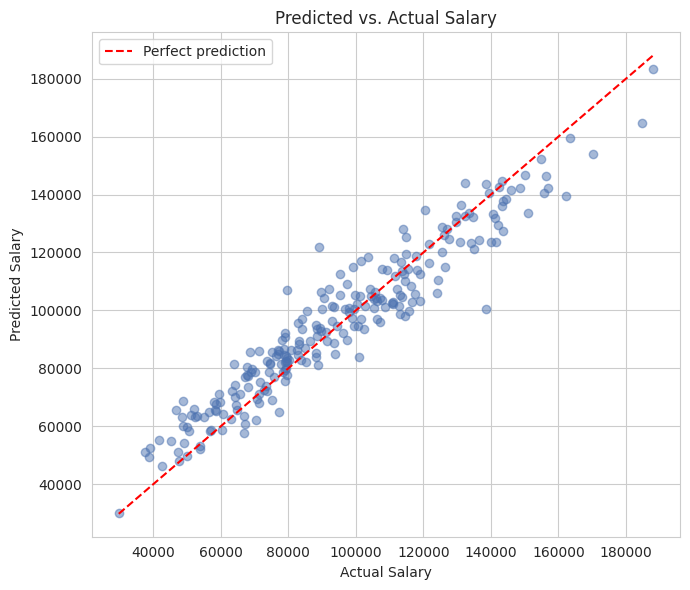

In [ ]:
# Predicted vs actual plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_pred, alpha=0.5, color="#4C72B0")
lims = [min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Predicted vs. Actual Salary")
plt.legend()
plt.tight_layout()
plt.show()


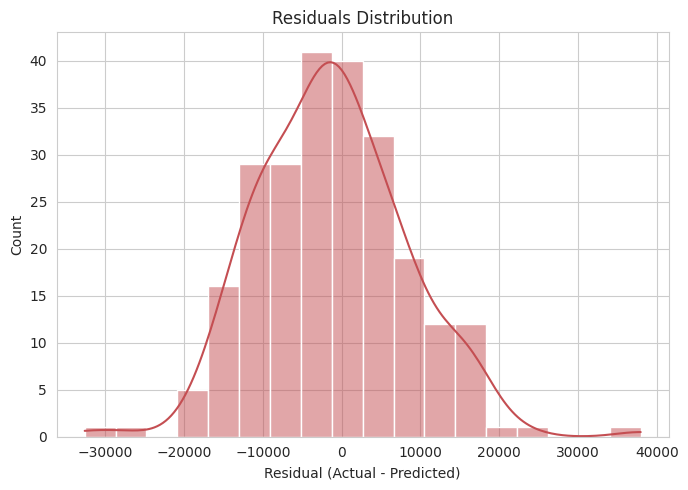

In [ ]:
# Residual analysis
residuals = y_test.values - final_pred

plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, color="#C44E52")
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


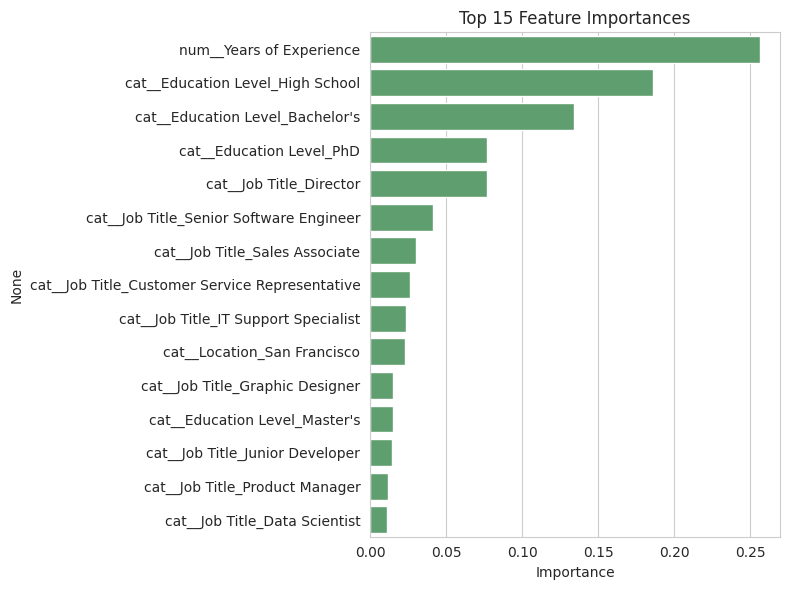

In [ ]:
# Feature importance (only meaningful for tree-based models)
model_step = final_model.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
    importances = pd.Series(model_step.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, color="#55A868")
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


In [ ]:
import os
os.makedirs("../model_artifacts", exist_ok=True)

joblib.dump(final_model, "../model_artifacts/salary_model.pkl")

# Also save the list of expected input columns and their dtypes/categories,
# useful for building the Streamlit form dynamically.
metadata = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "categorical_options": {col: sorted(df[col].dropna().unique().tolist())
                             for col in categorical_features},
    "numeric_ranges": {col: (float(df[col].min()), float(df[col].max()))
                        for col in numeric_features},
    "target": TARGET,
    "test_mae": float(final_mae),
    "test_rmse": float(final_rmse),
    "test_r2": float(final_r2),
}

import json
with open("../model_artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Model and metadata exported to ../model_artifacts/")
print(json.dumps(metadata, indent=2))


Model and metadata exported to ../model_artifacts/
{
  "numeric_features": [
    "Age",
    "Years of Experience"
  ],
  "categorical_features": [
    "Gender",
    "Education Level",
    "Job Title",
    "Location"
  ],
  "categorical_options": {
    "Gender": [
      "Female",
      "Male"
    ],
    "Education Level": [
      "Bachelor's",
      "High School",
      "Master's",
      "PhD"
    ],
    "Job Title": [
      "Account Manager",
      "Business Analyst",
      "Customer Service Representative",
      "Data Analyst",
      "Data Scientist",
      "Director",
      "Financial Analyst",
      "Graphic Designer",
      "HR Manager",
      "IT Support Specialist",
      "Junior Developer",
      "Marketing Manager",
      "Operations Manager",
      "Product Manager",
      "Project Manager",
      "Research Scientist",
      "Sales Associate",
      "Sales Manager",
      "Senior Software Engineer",
      "Software Engineer"
    ],
    "Location": [
      "Atlanta",
      "Au

## Summary

| Model | MAE | RMSE | R2 |
|---|---|---|---|
| Linear Regression (baseline) | computed above | computed above | computed above |
| Tuned Random Forest / Gradient Boosting (final) | computed above | computed above | computed above |

The exported pipeline (`salary_model.pkl`) bundles preprocessing and the
trained model together, ready to be loaded directly by
`model/predict.py` in the Streamlit application.
